In [18]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, Sequence, Callable
from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

In [19]:
# ============================================================
# Configuration:
#   -   Cut period to remove initialization bias
#   -   Remove failed operations from analysis
# ============================================================

# Cut period in seconds - operations in the first N seconds will be excluded
CUT_PERIOD_SECONDS = 10.0

def apply_cut_period(df: pd.DataFrame, cut_seconds: float = CUT_PERIOD_SECONDS) -> pd.DataFrame:
    """
    Filter out operations that started within the first cut_seconds of the run.
    This removes initialization bias from the analysis.
    """
    if len(df) == 0 or cut_seconds <= 0:
        return df
    
    t0 = df["ts_start"].min()
    cutoff_time = t0 + pd.Timedelta(seconds=cut_seconds)
    
    mask = df["ts_start"] >= cutoff_time
    return df[mask].copy()

def remove_failed_operations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove operations that failed (status != "success") from the analysis.
    This focuses the analysis on successful operations only.
    """
    if len(df) == 0:
        return df
    
    df = df[df["success"] == True].copy()

    return df


In [20]:
# ============================================================
# Import a dataframe from a CSV file and preprocess it for analysis.
# ============================================================

def load_summary(file_path: str) -> pd.DataFrame:
    # Load the data from the CSV file
    df = pd.read_csv(file_path)

    # Basic validation
    required = {"ts_start", "ts_end", "success", "latency_ms"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts_start and ts_end columns to datetime format
    df['ts_start'] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    df['ts_end'] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")

    return df

def load_events(file_path: str) -> pd.DataFrame:
    # Load the data from the JSONL file
    df = pd.read_json(file_path, lines=True)

    # Basic validation
    required = {"phase", "nodeId", "reqId"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts column to datetime format
    df['ts'] = pd.to_datetime(df["ts"], utc=True, errors="coerce")

    # Change the nodeId from "15" to "node_15"
    df['nodeId'] = df['nodeId'].apply(lambda x: f"node_{x}" if isinstance(x, int) else x)

    return df

In [21]:
# ============================================================
# Given summary and events return summary with reason of failure for failed operations.
# ============================================================

DEC_PREFIX = "DEC_"

def classify_from_phase(phase: str, op: str) -> Optional[str]:
    """
    Map DEC event phase to failure cause.
    Returns one of: TIMEOUT, UNAVAILABLE, SUCCESS, None
    """
    if not phase:
        return None
    p = str(phase).strip().upper()

    # We only care about DEC events
    if not p.startswith(DEC_PREFIX):
        return None

    # Examples: DEC_GET_TIMEOUT, DEC_UPDATE_FAIL, DEC_GET_SUCCESS ...
    if op == "GET":
        if p == "DEC_GET_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_GET_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_GET_SUCCESS":
            return "SUCCESS"
    elif op == "UPDATE":
        if p == "DEC_UPDATE_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_UPDATE_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_UPDATE_SUCCESS":
            return "SUCCESS"

    # If you ever add other DEC_* phases, you can extend here
    return None

def enrich_summary_with_failure_reasons(summary: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich summary with failure reasons from events.
    Events use: nodeId (converted to "node_XX"), reqId
    Summary uses: node_id, req_id, op
    """
    # Filter events to only include DEC_ events
    dec_events = events[events["phase"].str.startswith(DEC_PREFIX, na=False)].copy()
    
    # Create a mapping of (nodeId, reqId) -> op from summary
    # Summary columns: node_id, req_id, op
    op_map = summary.set_index(["node_id", "req_id"])["op"].to_dict()
    
    # Classify each event using the phase and corresponding op
    def get_reason(row):
        # Events already have nodeId converted to "node_XX" format by load_events
        op = op_map.get((row["nodeId"], row["reqId"]))
        if op:
            return classify_from_phase(row["phase"], op)
        return None
    
    dec_events["reason"] = dec_events.apply(get_reason, axis=1)
    
    # Create a mapping of (nodeId, reqId) to reason (only keep non-None reasons)
    reason_map = dec_events[dec_events["reason"].notna()].set_index(["nodeId", "reqId"])["reason"].to_dict()
    
    # Create a new column in the summary for the failure reason
    # If not found in DEC_ events (i.e., INT_ events), assign "REJECTED"
    summary["failure_reason"] = summary.apply(
        lambda row: reason_map.get((row["node_id"], row["req_id"]), "REJECTED") if not row["success"] else None,
        axis=1
    )
    
    return summary


In [22]:

# ============================================================
# 2) Run-level (per-run) estimators
#    Each returns ONE number per run
# ============================================================

def run_mean_latency_ms(df: pd.DataFrame) -> float:
    """Mean latency in ms for this run."""
    return float(df["latency_ms"].astype(float).mean())


def run_quantile_latency_ms(df: pd.DataFrame, q: float) -> float:
    """Latency quantile (e.g. q=0.5 for median, 0.9, 0.99) for this run."""
    return float(df["latency_ms"].astype(float).quantile(q))


def run_throughput_ops_per_s(df: pd.DataFrame) -> float:
    """
    Throughput = completed ops / elapsed seconds in the run window.
    Uses ts_start min and ts_end max.
    """

    t0 = df["ts_start"].min()
    t1 = df["ts_end"].max()
    elapsed_s = (t1 - t0).total_seconds()

    if elapsed_s <= 0:
        return float("nan")

    return float(len(df) / elapsed_s)

def run_failure_rate(df: pd.DataFrame) -> float:
    """Failure rate = (# failed ops) / (# total ops) in this run."""
    total = len(df)
    if total == 0:
        return float("nan")
    fails = int((df["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_update(df: pd.DataFrame) -> float:
    """Failure rate for update operations only."""
    updates = df[df["op"] == "UPDATE"]
    total = len(updates)
    if total == 0:
        return float("nan")
    fails = int((updates["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_read(df: pd.DataFrame) -> float:
    """Failure rate for read operations only."""
    reads = df[df["op"] == "GET"]
    total = len(reads)
    if total == 0:
        return float("nan")
    fails = int((reads["success"] == False).sum())
    return float(fails / total)

def run_request_per_node(df: pd.DataFrame) -> np.array:
    """Number of requests per node"""
    return df.groupby("node_id")["op"].count().values


def run_request_per_key(df: pd.DataFrame, keyspace: int = 50) -> np.ndarray:
    
    # discard non-data operations
    df_valid = df[df["key"] != -1]

    # Check I do not have outliers
    if not df_valid["key"].between(1, keyspace).all():
        raise ValueError("Found keys outside expected range 1..50")

    # count per key
    counts = df_valid.groupby("key").size()

    # align to full keyspace [1..keyspace]
    return (
        counts
        .reindex(range(1, keyspace + 1), fill_value=0)
        .to_numpy(dtype=np.int64)
    )

def run_failure_rate_per_reason(df: pd.DataFrame) -> Dict[str, float]:
    """
    Failure rate broken down by failure reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    Returns the percentage of total operations that failed with each reason.
    """
    total_ops = len(df)
    if total_ops == 0:
        return {}
    
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    
    # Convert to rates (percentage of total operations)
    rates = {}
    for reason, count in failure_counts.items():
        rates[reason] = float(count / total_ops)
    
    rates["SUCCESS"] = float((df["success"] == True).sum() / total_ops)
    
    return rates

def run_failure_count_per_reason(df: pd.DataFrame) -> Dict[str, int]:
    """
    Count of failures by reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    """
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    failure_counts["SUCCESS"] = (df["success"] == True).sum()
    return failure_counts.to_dict()

def run_latency_membership_operations(df: pd.DataFrame, operation: str) -> float:
    if operation not in ["JOIN", "LEAVE"]:
        raise ValueError("Operation must be 'JOIN' or 'LEAVE'")
    
    # filter to the specified operation
    op_df = df[df["op"] == operation]
    if len(op_df) == 0:
        return float("nan")
    
    # get latency of the first successful operation of this type
    successful_ops = op_df[op_df["success"] == True]
    if len(successful_ops) == 0:
        return float("nan")
    latency_ms = successful_ops["latency_ms"].astype(float).iloc[0]
    
    return latency_ms

In [23]:
# ============================================================
# 3) Confidence intervals across runs
# ============================================================

def t_critical_95(df: int) -> float:
    """
    95% two-sided t critical values for small df (1..30).
    Enough for b=10/20/30.
    If df is larger, we approximate with 1.96.
    """
    table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
        21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
        26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042
    }
    return table.get(df, 1.96)

def ci_mean_t(values: Sequence[float], confidence: float = 0.95) -> Tuple[float, float, float]:
    """
    Student-t CI for the mean of run-level values.
    Returns (mean, lo, hi).
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n < 2:
        return (float("nan"), float("nan"), float("nan"))

    mean = sum(xs) / n
    # sample standard deviation (unbiased)
    var = sum((x - mean) ** 2 for x in xs) / (n - 1)
    s = math.sqrt(var)
    se = s / math.sqrt(n)

    # We keep it simple: assume 95% by default
    if abs(confidence - 0.95) > 1e-9:
        raise ValueError("This simple helper supports only 95% CI. Extend if needed.")
    tcrit = t_critical_95(n - 1)

    lo = mean - tcrit * se
    hi = mean + tcrit * se
    return (mean, lo, hi)

def ci_per_key(runs: Sequence[Sequence[float]], confidence: float = 0.95):
    """
    runs: R x K matrix (R runs, K keys)
    returns: list of (mean, lo, hi) of length K
    """
    if not runs:
        return []

    R = len(runs)
    K = len(runs[0])

    # Optional sanity check
    for r in runs:
        if len(r) != K:
            raise ValueError("All runs must have same number of keys")

    # Transpose: get values per key across runs
    results = []
    for k in range(K):
        values_for_key_k = [runs[r][k] for r in range(R)]
        results.append(ci_mean_t(values_for_key_k, confidence))

    return results


def bootstrap_ci_stat(
    values: Sequence[float],
    stat_fn: Callable[[List[float]], float],
    confidence: float = 0.95,
    n_boot: int = 5000,
    seed: int = 0,
) -> Tuple[float, float, float]:
    """
    Bootstrap percentile CI for a statistic over run-level values.
    Returns (point_estimate, lo, hi).

    IMPORTANT: values here should be run-level statistics (e.g., 10 medians),
    not per-operation samples.
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n == 0:
        return (float("nan"), float("nan"), float("nan"))

    rng = random.Random(seed)

    point = stat_fn(xs)

    boot_stats = []
    for _ in range(n_boot):
        sample = [xs[rng.randrange(n)] for _ in range(n)]
        boot_stats.append(stat_fn(sample))

    boot_stats.sort()

    alpha = 1.0 - confidence
    lo_idx = int(math.floor((alpha / 2) * n_boot))
    hi_idx = int(math.ceil((1 - alpha / 2) * n_boot)) - 1
    lo = boot_stats[max(0, min(lo_idx, n_boot - 1))]
    hi = boot_stats[max(0, min(hi_idx, n_boot - 1))]

    return (point, lo, hi)

def median_stat(xs: List[float]) -> float:
    """Median of a list (no numpy)."""
    ys = sorted(xs)
    n = len(ys)
    mid = n // 2
    if n % 2 == 1:
        return float(ys[mid])
    return float((ys[mid - 1] + ys[mid]) / 2)


def quantile_stat(q: float) -> Callable[[List[float]], float]:
    """
    Return a stat function that computes a quantile of a list via
    simple linear interpolation between sorted points.
    """
    def _q(xs: List[float]) -> float:
        ys = sorted(xs)
        n = len(ys)
        if n == 1:
            return float(ys[0])
        # position in [0, n-1]
        pos = q * (n - 1)
        lo = int(math.floor(pos))
        hi = int(math.ceil(pos))
        if lo == hi:
            return float(ys[lo])
        w = pos - lo
        return float(ys[lo] * (1 - w) + ys[hi] * w)
    return _q

In [24]:
def plot_cumulative_averages(data_dir: Path, apply_cut: bool = True):
    """
    Plot cumulative average latency and throughput over time for all runs in a folder.
    
    Args:
        data_dir: Path to folder containing run subfolders
        apply_cut: Whether to apply the cut period filter
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    ax_lat, ax_thr = axes
    
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
            
        # Load data
        df = load_summary(folder / "summary.csv")
        
        if apply_cut:
            df = apply_cut_period(df)
        
        # Filter successful operations only
        df = remove_failed_operations(df)
        
        if len(df) == 0:
            continue
        
        # Sort by end time
        df = df.sort_values('ts_end').reset_index(drop=True)
        
        # Cumulative average latency
        cumsum_latency = df['latency_ms'].cumsum()
        cum_avg_latency = cumsum_latency / (np.arange(len(df)) + 1)
        
        # Cumulative average throughput (ops/s from start to each point)
        t0 = df['ts_start'].min()
        elapsed_seconds = (df['ts_end'] - t0).dt.total_seconds()
        cum_avg_throughput = (np.arange(len(df)) + 1) / elapsed_seconds
        
        # Plot
        label = folder.name
        ax_lat.plot(elapsed_seconds, cum_avg_latency, label=label, alpha=0.7)
        ax_thr.plot(elapsed_seconds, cum_avg_throughput, label=label, alpha=0.7)
    
    # Configure latency plot
    ax_lat.set_xlabel('Time (seconds)')
    ax_lat.set_ylabel('Cumulative Average Latency (ms)')
    ax_lat.set_title(f'Cumulative Average Latency over Time - {data_dir.name}')
    ax_lat.legend()
    ax_lat.grid(True, alpha=0.3)
    
    # Configure throughput plot
    ax_thr.set_xlabel('Time (seconds)')
    ax_thr.set_ylabel('Cumulative Average Throughput (ops/s)')
    ax_thr.set_title(f'Cumulative Average Throughput over Time - {data_dir.name}')
    ax_thr.legend()
    ax_thr.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

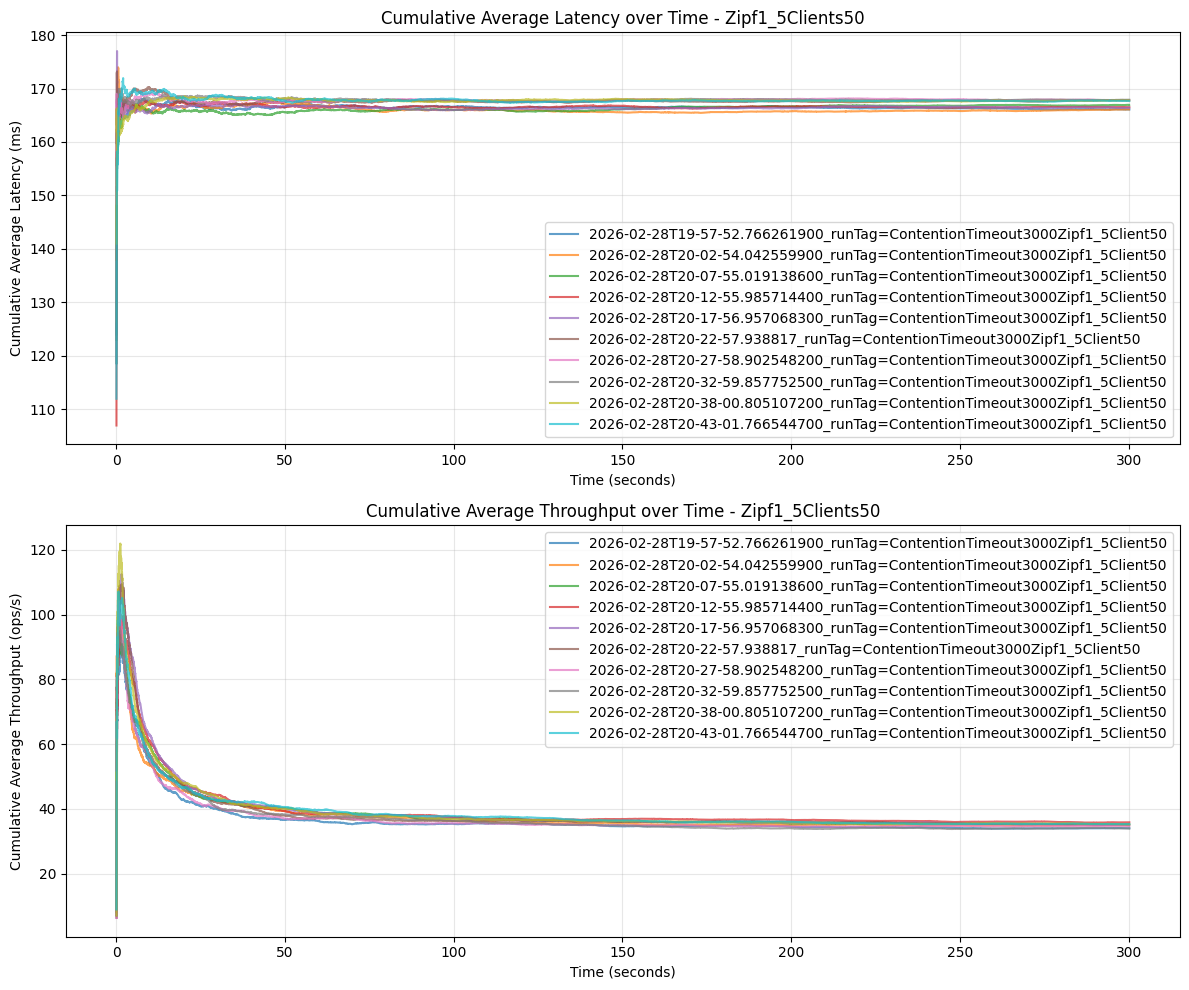

In [22]:
DATA_DIR = Path("Zipf1_5Clients50")
SUMMARY_NAME = "summary.csv"

plot_cumulative_averages(DATA_DIR, apply_cut=False)

In [9]:
def plot_cumulative_averages_across_runs(data_dir: Path, apply_cut: bool = True):
    """
    Plot cumulative average latency and throughput across all runs in a configuration.
    This aggregates all operations from all runs and shows the cumulative average.
    
    Args:
        data_dir: Path to folder containing run subfolders
        apply_cut: Whether to apply the cut period filter
    """
    # Collect all operations from all runs
    all_operations = []
    
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
            
        # Load data
        df = load_summary(folder / "summary.csv")
        
        if apply_cut:
            df = apply_cut_period(df)
        
        # Filter successful operations only
        df = remove_failed_operations(df)
        
        if len(df) == 0:
            continue
        
        all_operations.append(df)
    
    if len(all_operations) == 0:
        print(f"No data found in {data_dir}")
        return
    
    # Combine all runs
    combined_df = pd.concat(all_operations, ignore_index=True)
    
    # Sort by end time
    combined_df = combined_df.sort_values('ts_end').reset_index(drop=True)
    
    # Cumulative average latency
    cumsum_latency = combined_df['latency_ms'].cumsum()
    cum_avg_latency = cumsum_latency / (np.arange(len(combined_df)) + 1)
    
    # Cumulative average throughput (ops/s from start to each point)
    t0 = combined_df['ts_start'].min()
    elapsed_seconds = (combined_df['ts_end'] - t0).dt.total_seconds()
    cum_avg_throughput = (np.arange(len(combined_df)) + 1) / elapsed_seconds
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=(6, 5))
    ax_lat, ax_thr = axes
    
    # Plot latency
    ax_lat.plot(elapsed_seconds, cum_avg_latency, label=data_dir.name, alpha=0.7, linewidth=2)
    ax_lat.set_xlabel('Time (seconds)')
    ax_lat.set_ylabel('Cumulative Average Latency (ms)')
    ax_lat.set_title(f'Cumulative Average Latency Across All Runs - {data_dir.name}')
    ax_lat.legend()
    ax_lat.grid(True, alpha=0.3)
    
    # Plot throughput
    ax_thr.plot(elapsed_seconds, cum_avg_throughput, label=data_dir.name, alpha=0.7, linewidth=2)
    ax_thr.set_xlabel('Time (seconds)')
    ax_thr.set_ylabel('Cumulative Average Throughput (ops/s)')
    ax_thr.set_title(f'Cumulative Average Throughput Across All Runs - {data_dir.name}')
    ax_thr.legend()
    ax_thr.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nConfiguration: {data_dir.name}")
    print(f"  Total runs: {len(all_operations)}")
    print(f"  Total successful operations: {len(combined_df)}")
    print(f"  Final cumulative average latency: {cum_avg_latency.iloc[-1]:.2f} ms")
    print(f"  Final cumulative average throughput: {cum_avg_throughput.iloc[-1]:.2f} ops/s")

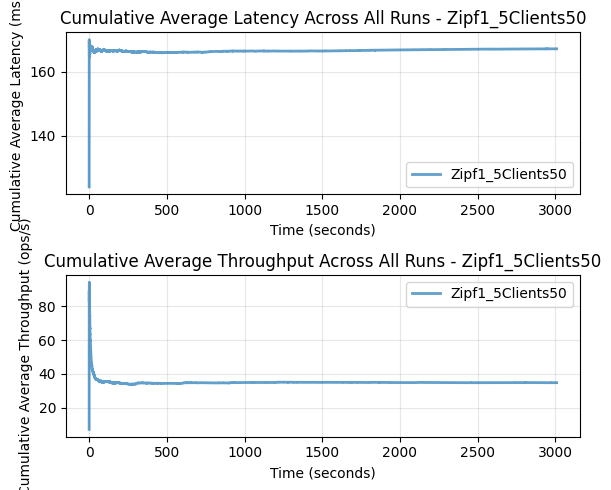


Configuration: Zipf1_5Clients50
  Total runs: 10
  Total successful operations: 104820
  Final cumulative average latency: 167.09 ms
  Final cumulative average throughput: nan ops/s


In [24]:
plot_cumulative_averages_across_runs(Path("Zipf1_5Clients50"), apply_cut=False)

Processing JoinN5...


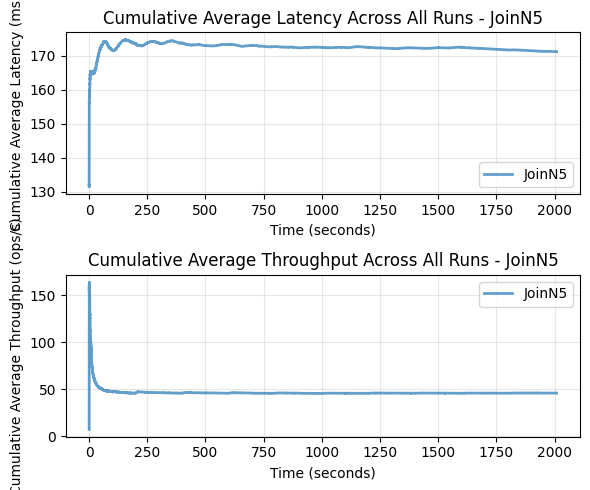


Configuration: JoinN5
  Total runs: 10
  Total successful operations: 92707
  Final cumulative average latency: 171.24 ms
  Final cumulative average throughput: nan ops/s
Processing JoinN7...


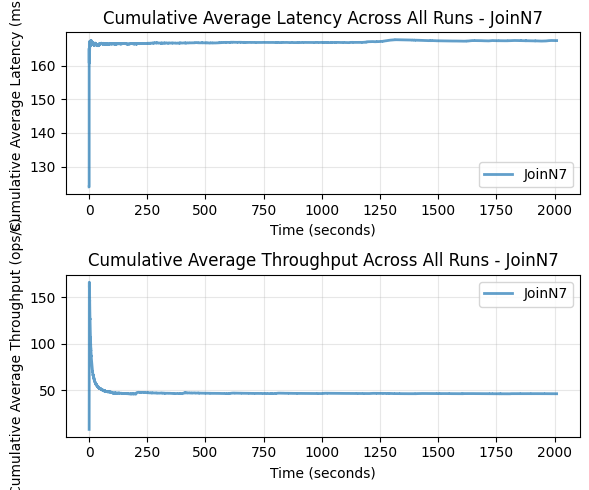


Configuration: JoinN7
  Total runs: 10
  Total successful operations: 93132
  Final cumulative average latency: 167.45 ms
  Final cumulative average throughput: nan ops/s
Processing LeaveN5...


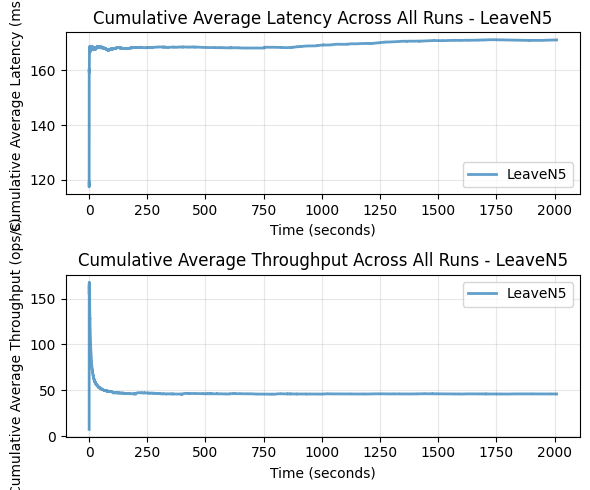


Configuration: LeaveN5
  Total runs: 10
  Total successful operations: 92385
  Final cumulative average latency: 170.98 ms
  Final cumulative average throughput: nan ops/s


In [9]:
BASE_DIR = Path("./")

final_stats = {}

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        plot_cumulative_averages_across_runs(Path(folder), apply_cut=False)

In [15]:
# You can adjust CUT_PERIOD_SECONDS at the top to change the cut period
# Current setting: first 10 seconds of each run are excluded from analysis
DATA_DIR = Path("LeaveN5")
SUMMARY_NAME = "summary.csv"

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        df = load_summary(folder / SUMMARY_NAME)
        df = apply_cut_period(df)
        filan_df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))
        print(f"Run: {folder.name}")
        print("Latency of membership operations:")
        print(f"  JOIN: {run_latency_membership_operations(filan_df, 'JOIN')}")
        print(f"  LEAVE: {run_latency_membership_operations(filan_df, 'LEAVE')}")

Run: 2026-03-02T16-07-00.696522_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 97.0
Run: 2026-03-02T16-10-21.963574400_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 109.0
Run: 2026-03-02T16-13-42.923785500_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 109.0
Run: 2026-03-02T16-17-03.883175200_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 126.0
Run: 2026-03-02T16-20-24.837469300_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 116.0
Run: 2026-03-02T16-23-45.802399900_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 134.0
Run: 2026-03-02T16-27-06.776227400_runTag=ReconfigurationTimeLeaveZipf0N5
Latency of membership operations:
  JOIN: nan
  LEAVE: 115.0
Run: 2026-03-02T16-30-27.717687200_runTag=ReconfigurationTi

In [10]:
# ============================================================
# Compute statistics across runs and confidence intervals
# ============================================================

def compute_stat_across_runs(
    data_dir: Path,
) -> Dict:
    """
    Compute statistics across runs and confidence intervals.
    Returns a dictionary of statistic name -> (point_estimate, ci_lo, ci_hi).
    """
    p50_r = []
    p50_w = []
    p95_r = []
    p95_w = []
    p99_r = []
    p99_w = []

    throughput = []
    throughput_r = []
    throughput_w = []

    success_rate = []
    timeout_rate = []
    busy_rate = []
    per_key_operations = []

    latency_join = []
    latency_leave = []

    for folder in data_dir.iterdir():
        if folder.is_dir():
            df = load_summary(folder / SUMMARY_NAME)
            df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))

            df = apply_cut_period(df)

            df_success = remove_failed_operations(df)

            # Now I compute run-level stats
            df_r = df_success[df_success["op"] == "GET"]
            df_w = df_success[df_success["op"] == "UPDATE"]

            p50_r.append(run_quantile_latency_ms(df_r, 0.5))
            p50_w.append(run_quantile_latency_ms(df_w, 0.5))
            p95_r.append(run_quantile_latency_ms(df_r, 0.95))
            p95_w.append(run_quantile_latency_ms(df_w, 0.95))
            p99_r.append(run_quantile_latency_ms(df_r, 0.99))
            p99_w.append(run_quantile_latency_ms(df_w, 0.99))

            throughput.append(run_throughput_ops_per_s(df_success))
            throughput_r.append(run_throughput_ops_per_s(df_r))
            throughput_w.append(run_throughput_ops_per_s(df_w))

            rates = run_failure_rate_per_reason(df)
            success_rate.append(rates.get("SUCCESS", 0))
            timeout_rate.append(rates.get("TIMEOUT", 0))
            busy_rate.append(rates.get("UNAVAILABLE", 0) + rates.get("REJECTED", 0))
            per_key_operations.append(run_request_per_key(df))  # average ops per key

            latency_join.append(run_latency_membership_operations(df_success, "JOIN"))
            latency_leave.append(run_latency_membership_operations(df_success, "LEAVE"))
    
    # Compute mean and CI for each metric
    summary_stats = {
        # Read latency percentiles
        "p50_read_ms": {
            "median": bootstrap_ci_stat(p50_r, median_stat)
        },
        "p95_read_ms": {
            "median": bootstrap_ci_stat(p95_r, median_stat)
        },
        "p99_read_ms": {
            "median": bootstrap_ci_stat(p99_r, median_stat)
        },
        
        # Write latency percentiles
        "p50_write_ms": {
            "median": bootstrap_ci_stat(p50_w, median_stat)
        },
        "p95_write_ms": {
            "median": bootstrap_ci_stat(p95_w, median_stat)
        },
        "p99_write_ms": {
            "median": bootstrap_ci_stat(p99_w, median_stat)
        },
        
        # Throughput metrics
        "throughput_ops_per_s": {
            "mean": ci_mean_t(throughput),
        },
        "throughput_read_ops_per_s": {
            "mean": ci_mean_t(throughput_r),
        },
        "throughput_write_ops_per_s": {
            "mean": ci_mean_t(throughput_w),
        },
        
        # Success and failure rates
        "success_rate": {
            "mean": ci_mean_t(success_rate),
        },
        "timeout_rate": {
            "mean": ci_mean_t(timeout_rate),
        },
        "busy_rate": {
            "mean": ci_mean_t(busy_rate),
        },

        # Per key operations
        "per_key_operations": {
            "array_means": ci_per_key(per_key_operations),
        },
        # Latency of membership operations
        "latency_join_ms": {
            "median": bootstrap_ci_stat(latency_join, median_stat)
        },
        "latency_leave_ms": {
            "median": bootstrap_ci_stat(latency_leave, median_stat)
        }
    }

    return summary_stats

In [12]:
BASE_DIR = Path("./")

final_stats = {}
SUMMARY_NAME = "summary.csv"

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        stats = compute_stat_across_runs(Path(folder))
        final_stats[folder.name] = stats

Processing JoinN3...
Processing JoinN5...
Processing JoinN7...
Processing LeaveN3...
Processing LeaveN5...
Processing LeaveN7...


In [13]:
for config, stats in final_stats.items():
    print(f"\nConfiguration: {config}")
    print(f" Median join latency (ms): {stats['latency_join_ms']['median'][0]:.2f} (CI: {stats['latency_join_ms']['median'][1]:.2f} - {stats['latency_join_ms']['median'][2]:.2f})")
    print(f" Median leave latency (ms): {stats['latency_leave_ms']['median'][0]:.2f} (CI: {stats['latency_leave_ms']['median'][1]:.2f} - {stats['latency_leave_ms']['median'][2]:.2f})")


Configuration: JoinN3
 Median join latency (ms): 235.50 (CI: 215.00 - 265.00)
 Median leave latency (ms): 109.50 (CI: 109.00 - 110.00)

Configuration: JoinN5
 Median join latency (ms): 239.50 (CI: 214.50 - 269.50)
 Median leave latency (ms): 119.00 (CI: 119.00 - 119.00)

Configuration: JoinN7
 Median join latency (ms): 273.00 (CI: 236.00 - 298.00)
 Median leave latency (ms): nan (CI: nan - nan)

Configuration: LeaveN3
 Median join latency (ms): nan (CI: nan - nan)
 Median leave latency (ms): 117.00 (CI: 100.00 - 138.50)

Configuration: LeaveN5
 Median join latency (ms): nan (CI: nan - nan)
 Median leave latency (ms): 115.00 (CI: 109.00 - 126.00)

Configuration: LeaveN7
 Median join latency (ms): nan (CI: nan - nan)
 Median leave latency (ms): 125.00 (CI: 115.00 - 133.50)


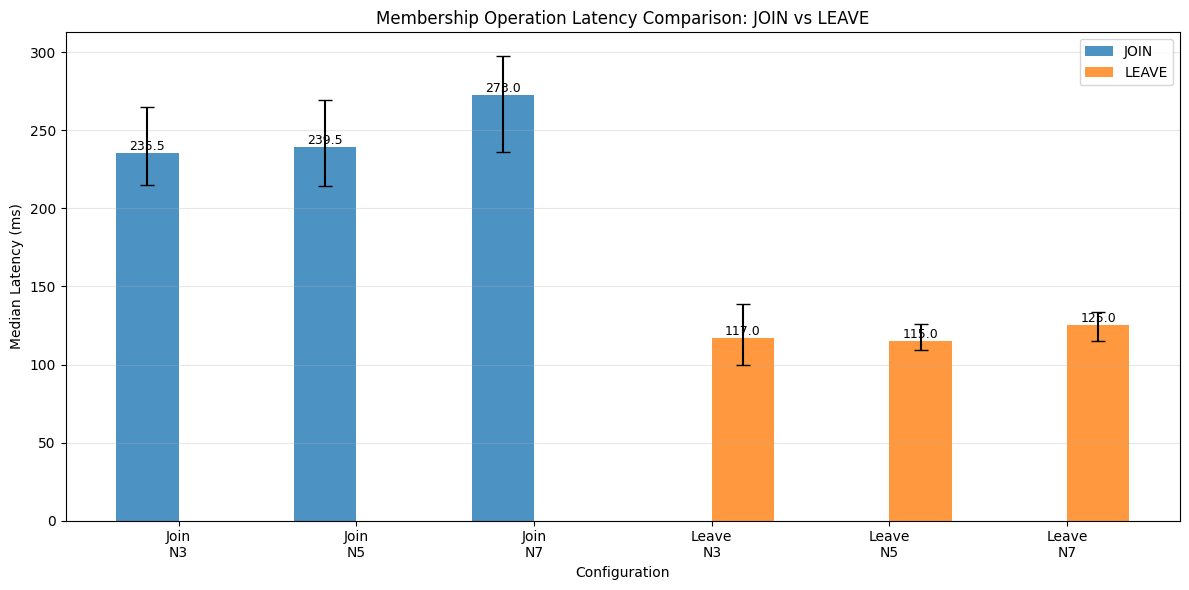


MEMBERSHIP OPERATION LATENCY COMPARISON
Configuration   JOIN (ms)                 LEAVE (ms)               
--------------------------------------------------------------------------------
Join N3         235.50 [215.00, 265.00]   nan [nan, nan]           
Join N5         239.50 [214.50, 269.50]   nan [nan, nan]           
Join N7         273.00 [236.00, 298.00]   nan [nan, nan]           
Leave N3        nan [nan, nan]            117.00 [100.00, 138.50]  
Leave N5        nan [nan, nan]            115.00 [109.00, 126.00]  
Leave N7        nan [nan, nan]            125.00 [115.00, 133.50]  


In [17]:
# Extract join and leave latencies from final_stats
configs = []
join_latencies = []
join_ci_lo = []
join_ci_hi = []
leave_latencies = []
leave_ci_lo = []
leave_ci_hi = []

# Collect data for each configuration
for config_name in ['JoinN3', 'JoinN5', 'JoinN7', 'LeaveN3', 'LeaveN5', 'LeaveN7']:
    if config_name in final_stats:
        config_type = None
        # Extract configuration type and size
        if config_name.startswith('Join'):
            config_type = 'Join'
            n = config_name.replace('Join', '')
        else:
            config_type = 'Leave'
            n = config_name.replace('Leave', '')
        
        configs.append(f"{config_type}\n{n}")
        
        # Get join latency
        if (config_type == 'Join'):
            join_pt, join_lo, join_hi = final_stats[config_name]['latency_join_ms']['median']
            join_latencies.append(join_pt)
            join_ci_lo.append(join_pt - join_lo)
            join_ci_hi.append(join_hi - join_pt)
            leave_latencies.append(float("nan"))  # placeholder for leave latency
            leave_ci_lo.append(float("nan"))  # placeholder for leave ci_lo
            leave_ci_hi.append(float("nan"))  # placeholder for leave ci_hi
        
        # Get leave latency
        if (config_type == 'Leave'):
            leave_pt, leave_lo, leave_hi = final_stats[config_name]['latency_leave_ms']['median']
            leave_latencies.append(leave_pt)
            leave_ci_lo.append(leave_pt - leave_lo)
            leave_ci_hi.append(leave_hi - leave_pt)
            join_latencies.append(float("nan"))
            join_ci_lo.append(float("nan"))
            join_ci_hi.append(float("nan"))

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(configs))
width = 0.35

# Plot bars with error bars
bars1 = ax.bar(x - width/2, join_latencies, width, 
               yerr=[join_ci_lo, join_ci_hi],
               label='JOIN', capsize=5, alpha=0.8)
bars2 = ax.bar(x + width/2, leave_latencies, width,
               yerr=[leave_ci_lo, leave_ci_hi],
               label='LEAVE', capsize=5, alpha=0.8)

# Customize the plot
ax.set_xlabel('Configuration')
ax.set_ylabel('Median Latency (ms)')
ax.set_title('Membership Operation Latency Comparison: JOIN vs LEAVE')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 80)
print("MEMBERSHIP OPERATION LATENCY COMPARISON")
print("=" * 80)
print(f"{'Configuration':<15} {'JOIN (ms)':<25} {'LEAVE (ms)':<25}")
print("-" * 80)
for i, config in enumerate(configs):
    config_clean = config.replace('\n', ' ')
    join_str = f"{join_latencies[i]:.2f} [{join_latencies[i]-join_ci_lo[i]:.2f}, {join_latencies[i]+join_ci_hi[i]:.2f}]"
    leave_str = f"{leave_latencies[i]:.2f} [{leave_latencies[i]-leave_ci_lo[i]:.2f}, {leave_latencies[i]+leave_ci_hi[i]:.2f}]"
    print(f"{config_clean:<15} {join_str:<25} {leave_str:<25}")